## Intercomparison of inverse modelling results

This notebook contains options to plot and compare results from different inverse models. The following variables can be investigated:

- Posterior and prior country fluxes, total from all sectors, and respective uncertainties
- Observed and posterior/prior modelled total mole fractions
- Posterior and prior modelled baseline mole fractions
- Posterior and prior bias mole fractions
- Posterior and prior mole fractions from the outer regions
- Observed repeatability/variability, model and total uncertainties
- Posterior and prior spatial fluxes

Future updates may include:

- Sector-level emissions
- Comparison between each model's country/region definition

### Input data:

- Flux and concentration netCDF files with model outputs
- json files with models, sites and species information
- (optional) netCDF file with country fluxes from bottom-up inventory
- (optional) netCDF file with baseline timestamps

Please refer to the User Guide for information on files format, filename convention and folder structure.

### Notebook setup:

1. Decide the verbosity level by assigning the logging level to `logging.INFO` or `logging.WARNING`.

2. Edit the `data_dir` to point towards where the model output is.

3. Set `presentation_mode` to `True`/`False` to use big font sizes (recommended for slides) or small font sizes (recommended for text documents). 

4. Update the `experiments` dictionary so that each key points towards the models you want to plot.

5. Run the cell below, before running any of the plotting code.

In [1]:
%load_ext autoreload
%autoreload 2
import logging
logging.basicConfig(level=logging.WARNING)

from fluxy.config import set_print_settings
from fluxy.io import read_config_files

### Path to results directory 
data_dir = '/work/bm1400/b301099/fluxy-mpi-bgc/mpi-bgc-intern/Output/'

### Set presentation_mode to True for bigger fonts
presentation_mode = False

### Group the models of interest in meaningful experiment names 
experiments = {'std_run'       :['CSR'],
               'wetcharts'     :['InTEM_NAME_EUROPE_EDGARWETCHART_31sites_std','ELRIS_NAME_EUROPE_EDGARWETCHART_31base',
                                 'RHIME_NAME_EUROPE_EDGAR-WetCHARTs_std_31sites']
              }

###################################

config_data = read_config_files()
annotate_coords = set_print_settings(presentation_mode)

### 1. Timeseries of country/region fluxes

##### Edit and run this cell to read and pre-process the data:

In [7]:
from fluxy.io import read_model_output, read_flux_total_fgases
from fluxy.operators.select import slice_flux
from fluxy.config import set_model_colors
from fluxy.config import set_model_labels

###################################
### edit variables in this block
species = 'co2' #options for individual species, or 'all_hfc' or 'all_pfc'
models = experiments['std_run'] #if using 'all_hfc' or 'all_pfc' use basic model names  (e.g. ['InTEM','ELRIS','RHIME']) and standard filenames (listed in config_data["models_info"]["standard_run"]["default"]) will be used for each species. 
                                #To use non standard filenames, do <model>_<config_key> : e.g. with ['ELRIS_elris-n2o'], the filenames will be looked in config_data["models_info"]["standard_run"]["elris-n2o"].
regions = ['GERMANY','UK','BENELUX','NW_EU2']
period = 'monthly' #inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']
country_flux_units_print = 'Gg yr-1' #desired units for the plot. Add "CO2-eq" to convert the mass to CO2 equivalent (e.g. "Gg CO2-eq yr-1")
start_date = '2018-01-01' #inclusive. Option to set as list of dates, e.g. ['2018-01-01','2019-01-01'] which is required for total fgases if one model is missing obs for a year
end_date = '2024-01-01' #not inclusive. Option to set as list of dates, e.g. ['2023-01-01','2022-01-01'] which is required for total fgases if one model is missing obs for a year
get_labels_from_file = False # If False, uses default labels. If True, uses labels in models_info.json.
###################################

ds_all_flux_scaled = {}
if 'co2' not in config_data["species_info"]:
    config_data["species_info"]["co2"] = {
        "species_print": "CO$_2$",
        "gwp": 1,
        "molar_mass": 44.01
    }
if 'all' in species:
    ds_all_flux_scaled = read_flux_total_fgases(data_dir,species,models,config_data,
                                                     regions,start_date,end_date,
                                                     period=period)
else:
    ds_all_flux = read_model_output(data_dir,"flux",species,models,config_data,period=period)

    for m in models:
        ds_all_flux_scaled[m] = slice_flux({m:ds_all_flux[m]},config_data,start_date,end_date,species=species,country_flux_units_print=country_flux_units_print)[m]

model_colors = set_model_colors(models)
model_labels = set_model_labels(models,config_data,get_labels_from_file)

ValueError: There are no variables in CSR with country flux units in the attributes. Scaling to Gg yr-1 cannot be applied.

#### Timeseries of country fluxes:

In [3]:
from fluxy.plots.flux_timeseries import plot_country_flux

###################################
### edit variables in this block
plot_inventory = False
inventory_years = None #If None, plots most recent. Or can choose list of years: ['2022','2023']
fix_y_axes = False #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
add_prior = True #if True: plots prior as dashed lines
add_prior_unc = False #if True: plots prior uncertainty as shaded area
set_global_leg = True #If True, plots one single legend instead of one legend per subplot.
country_codes_as_titles = False #If True, lists 3-letter country codes under region names in subplot titles. Set to None for no title.
plot_separate = True #If True, includes all model results as separate lines (or insert a list of boolean of the same length as models to specify which models to plot)
plot_combined = False #If True, combined results, averaged from all models (or insert a list of boolean of the same length as models to specify which models to combine)
resample = None #If None, no resample is done. Else resample the data to the given period (options 'year' and 'season' for yearly and seasonal averages)
resample_uncert_correlation = False #If True, uses mean uncertainty during resampling, if False, recalculates uncertainty assuming no correlation.
plot_resample_and_original = False #If True, plots both the resampled and original data
annex_mode = False #If True, replace the labels with more concise versions for NID Annexes.
rolling_mean = False ##If True, calculates a rolling mean of the data (insert a list of boolean of the same length as models to specify the models to smooth)
###################################

fig = plot_country_flux(ds_all_flux_scaled,
                        species,
                        regions,
                        config_data,
                        model_colors,
                        model_labels,
                        start_date,
                        end_date,
                        annex_mode,
                        plot_inventory,
                        inventory_years,
                        data_dir,
                        fix_y_axes,
                        add_prior,
                        add_prior_unc,
                        set_global_leg,
                        country_codes_as_titles=country_codes_as_titles,
                        plot_separate=plot_separate,
                        plot_combined=plot_combined,
                        resample=resample,
                        resample_uncert_correlation=resample_uncert_correlation,
                        plot_resample_and_original=plot_resample_and_original,
                        rolling_mean=rolling_mean,
                        return_res=True)

NameError: name 'model_colors' is not defined

Save plot here:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/flux_country.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 2. Modelled and observed mole fractions and/or baselines

##### Edit and run this cell to choose inputs and read in the data:

In [4]:
from fluxy.io import read_model_output
from fluxy.operators.select import slice_mf
from fluxy.config import set_model_colors
from fluxy.config import set_model_labels

###################################
### edit variables in this block
species = 'co2' 
site = 'MHD'
models = experiments['std_run']
period = 'yearly'  #inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']
mf_units_print = 'ppt'
start_date = '2018-01-01' #inclusive
end_date = '2019-01-01'   #not inclusive
baseline_site = None #'MHD', 'JFJ' or 'CMN'. If None, does not mask by baseline time
get_labels_from_file = False # If False, uses default labels. If True, uses labels from config file.
###################################

ds_all_mf = read_model_output(data_dir,'concentration',species,models,config_data,period=period)

ds_all_mf_sliced = slice_mf(ds_all_mf.copy(),start_date,end_date,site,baseline_site=baseline_site,
                              data_dir=data_dir,
                              mf_units_print=mf_units_print)

model_colors = set_model_colors(models)
model_labels = set_model_labels(models,config_data,get_labels_from_file)

#### Plot timestamps with data at each site:

In [ ]:
from fluxy.plots.mf_timeseries import plot_sites_timeseries

fig = plot_sites_timeseries(ds_all_mf,'mf_posterior',start_date,end_date,model_colors,model_labels, margin=0.2)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/sites.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries plot, separated by model:

In [ ]:
from fluxy.plots.mf_timeseries import plot_mf_timeseries

###################################
### edit variables in this block
# Variables and respective uncertainties to plot
include = {'mf_observed'   : None,
           'mf_posterior' : 'percentile_mf_posterior'
           }

# To plot the histogram of the variables in "include", set "diff_include" to None
# To plot the histogram of Obs-variable, set "diff_include" to the desired variable to be subtracted
diff_include = ['mf_posterior']

# To choose y-axis limits set y_lim=[min_value,max_value]
y_lim = None
###################################

###################################
### options for variables to include
# mf_observed               - total observed mole fraction
# mf_observed_repeatability - observed repeatability mole fraction uncertainty
# mf_observed_variability   - observed variability mole fraction uncertainty
# stdev_mf_model            - model mole fraction uncertainty
# stdev_mf_total            - total mole fraction uncertainty
# mf_prior                  - prior total mole fraction
# mf_posterior              - posterior total mole fraction
# mf_priorBC                - prior baseline
# mf_posteriorBC            - posterior baseline
# mf_prior_bias             - prior bias added to site
# mf_posterior_bias         - posterior bias added to site
# mf_priorOUTER             - prior mole fractions only from outer regions
# mf_posteriorOUTER         - posterior mole fractions only from outer regions

### options for uncertainties to plot as error bars/shaded area
# mf_observed_repeatability - observed repeatability mole fraction uncertainty
# mf_observed_variability   - observed variability mole fraction uncertainty
# stdev_mf_model            - model mole fraction uncertainty
# uYtotal                   - total mole fraction uncertainty
# percentile_mf_prior       - prior mole fraction uncertainty
# percentile_mf_posterior   - posterior mole fraction uncertainty
###################################

fig = plot_mf_timeseries(ds_all_mf_sliced,species,site,
                                    model_colors,model_labels,config_data,annotate_coords,presentation_mode,
                                    plot_type='separate',
                                    include=include,
                                    diff_include=diff_include,
                                    y_lim=y_lim)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/mf_posterior_timeseries.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries plot, all models together:

In [ ]:
from fluxy.plots.mf_timeseries import plot_mf_timeseries

###################################
### edit variables in this block (see instructions above)
include = {'mf_posterior' : 'percentile_mf_posterior'}
diff_include=['mf_posterior']
y_lim=None
###################################

fig = plot_mf_timeseries(ds_all_mf_sliced,species,site,
                                    model_colors,model_labels,config_data,annotate_coords,presentation_mode,
                                    plot_type='together',
                                    include=include,
                                    diff_include=diff_include,
                                    y_lim=y_lim)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/mf_posterior_allmodels.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Absolute differences between two models:

In [ ]:
from fluxy.operators.mf import compute_mf_difference
from fluxy.plots.mf_timeseries import plot_mf_timeseries

###################################
### edit variables in this block
models_to_subtract = models[:2] # Models to subtract (must be a list of 2 elements)
include = {'mf_observed': None}        # Variables to plot (dict values must be set to None)
###################################

ds_diff = compute_mf_difference(ds_all_mf_sliced.copy(), models_to_subtract)

fig = plot_mf_timeseries(ds_diff,species,site,
                        model_colors,model_labels,config_data,annotate_coords,presentation_mode,
                        plot_type='diff',
                        include=include,
                        diff_include=None,
                        y_lim=None)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/mf_posterior_diff.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Calculate and plot stats for the fit to obs:

In [ ]:
from fluxy.operators.select import slice_mf
from fluxy.operators.mf import stats_mf
from fluxy.plots.mf_stats import plot_stats_mf


###################################
### edit variables in this block
stats_to_plot = ['pearson', 'bias', 'crmse']
what_to_compare = 'posterior_above_BC'
stats_ylim = {"pearson": [0,1], "bias": [-1.5,0.5], "crmse": [0,1.5] }    # or set it to None
get_labels_from_file = True # If False, uses default labels. If True, uses labels from config file.


### Implemented statistics (stats_to_plot)
# pearson - Pearson correlation coefficient
# bias    - Mean difference
# rmse    - RMSE
# nrmse   - Normalised RMSE (division by mean observation)
# crmse   - Centered (bias-corrected) RMSE
# sd_obs  - Standard deviation of observations 
# sd_sim  - Standard deviation of simulation 
# sd_res  - Standard deviation of residuals
# nn      - Number of observation-simulation pairs 
###################################

ds_all_allsites = slice_mf(ds_all_mf.copy(), 
                        start_date,
                        end_date,site=None,
                        baseline_site=baseline_site,
                        data_dir=data_dir,
                        mf_units_print=mf_units_print)

model_labels = set_model_labels(models,config_data,get_labels_from_file)

stats = stats_mf(ds_all_allsites, stats_type=what_to_compare)

fig = plot_stats_mf(stats=stats, 
                    stats_to_plot=stats_to_plot, 
                    species=species,
                    model_colors=model_colors, 
                    model_labels=model_labels, 
                    config_data=config_data, 
                    mf_units_print=mf_units_print,
                    stats_type=what_to_compare,
                    stats_ylim=stats_ylim,
                    start_date=start_date, 
                    end_date=end_date)

Save plot:

In [ ]:
#output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 3. Spatial maps of country/region fluxes

In [9]:
from fluxy.io import read_model_output
from fluxy.operators.select import slice_flux
from fluxy.config import set_model_labels

###################################
### edit variables in this block
species = 'co2'
start_date = '2018-01-01' 
end_date = '2024-01-01'
models = experiments['std_run']
period = 'monthly' # inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']
flux_units_print = 'kg km-2 yr-1'
get_labels_from_file = False # If False, uses default labels. If True, uses labels from config file.
###################################

ds_all_flux = read_model_output(data_dir,"flux",species,models,config_data,period=period)

ds_all_flux_scaled = {}
for m in models:
    ds_all_flux_scaled[m] = slice_flux({m:ds_all_flux[m]},config_data,start_date,end_date,species=species,flux_units_print=flux_units_print)[m]

model_labels = set_model_labels(models,config_data,get_labels_from_file)

##### Prior and posterior fluxes comparison across models

/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/numpy/lib/function_base.py:4527: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


ValueError: too many values to unpack (expected 2)

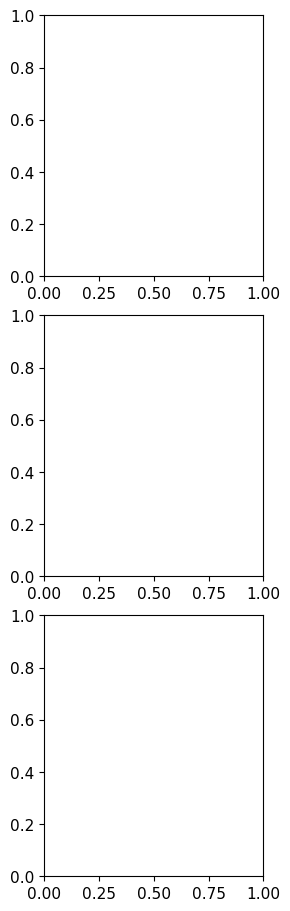

In [15]:
from fluxy.plots.flux_map import plot_flux_map

###################################
### edit variables in this block
region = 'UK'
add_sites = False
add_markers = ['london'] # Add a marker at given locations, options for 'paris', 'london', ... or any value [lon, lat]
season = None # If specified, plot the seasonal mean (only valable for monthly data), options for 'DJF', 'MAM', 'JJA' and 'SON'
set_fluxlim = 'auto' # Set flux colorbar limits: e.g.[0,10]|'auto' ('auto' = 99th percentile of flux_posterior)
plot_inversion_grid_flux = False # If True, plot fluxes at inversion's resolution. If False, plot fluxes at prior's resolution.
###################################
fig = plot_flux_map(ds_all_flux_scaled, species, region, config_data, model_labels, season=season,
                    add_sites=add_sites, add_markers=add_markers, set_fluxlim=set_fluxlim, plot_inversion_grid_flux=plot_inversion_grid_flux)

Save plot:

In [ ]:
#output_path = None
#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

##### Flux comparison between two models

In [5]:
from fluxy.plots.flux_map import plot_flux_map_model_comparison

###################################
### edit variables in this block
var = 'flux_total_posterior_inversion_grid'
models_plot = models[:2]
region = 'FRA'
###################################

fig = plot_flux_map_model_comparison(ds_all_flux_scaled, var, models_plot, species, region, config_data, model_labels, 
                                     season=season, add_sites=add_sites, add_markers=add_markers, set_fluxlim=set_fluxlim)

ValueError: Models must be a list of exactly two strings.

Save plot:

In [ ]:
#output_path = None
#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

##### Plot prior, posterior or difference fluxes per time interval:

/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/n

ValueError: too many values to unpack (expected 2)

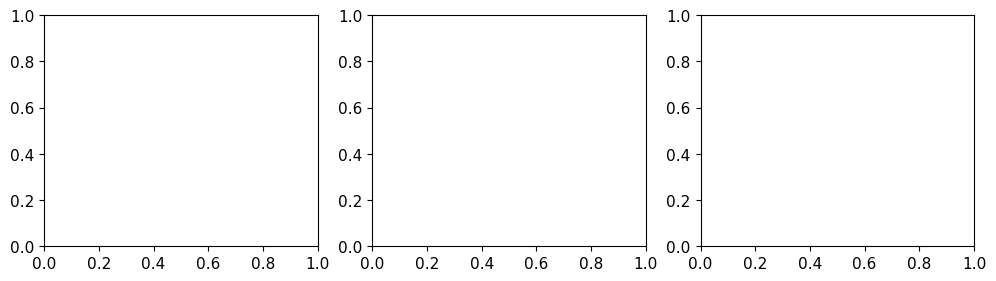

In [6]:
from fluxy.plots.flux_map import plot_flux_map_over_time

region = 'FRA'
chop_by = 'year' # Time unit of the averaging period (options for 'year', 'month' and 'season').
                 # Alternatively, a list of starting dates can be provided (format '2018-01-01') or a list of months (e.g., [[1:3], [7:9]])
dt = 2  # Number of time steps for year and month chop_by options
var = 'flux_total_posterior'  # Variable to be plotted. Extra options for 'posterior_prior_diff', 'posterior_mean_diff', 'posterior_prior_diff_inversion_grid', 'posterior_mean_diff_inversion_grid'.
plot_combined = False
add_sites = False   
add_markers = ['paris']
set_fluxlim = 'auto' # Set flux colorbar limits: e.g.[0,10]|'auto' ('auto' = 99th percentile of flux_posterior)
###################################

fig = plot_flux_map_over_time(ds_all_flux_scaled, var, species,region,config_data, model_labels, chop_by=chop_by, dt=dt,
                              plot_combined=plot_combined, add_sites=add_sites, add_markers=add_markers, set_fluxlim = set_fluxlim)

Save plot:

In [ ]:
#output_path = None
#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)